# 03. Correlation Analysis & Hypothesis Validation

**Pipeline:**
1. Aggregate news sentiment into 5-min windows (confidence-weighted)
2. Compute BTC price returns at T+5m, T+15m, T+30m, T+60m
3. Merge & compute Pearson correlation coefficients
4. Validate hypotheses

**Output:** `data/processed/merged_analysis.csv`

In [6]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.collector import load_all_news, load_klines
from src.sentiment import load_sentiment_results
from src.analyzer import (
    aggregate_to_windows,
    compute_price_returns,
    merge_sentiment_price,
    compute_correlations,
    compute_period_performance,
    run_analysis_pipeline,
    hypothesis_report,
)

## 1. Load Data

In [7]:
sentiment_df = load_sentiment_results()
klines_1m    = load_klines('1m')   # for correlation (1-min precision)
klines_1h    = load_klines('1h')   # for period performance

print(f'Sentiment rows : {len(sentiment_df):,}')
print(f'1m kline rows  : {len(klines_1m):,}')
print(f'1h kline rows  : {len(klines_1h):,}')

2026-04-20 17:39:40,825 [INFO] Loaded 4553546 kline rows (1m) from 105 files
2026-04-20 17:39:41,167 [INFO] Loaded 75907 kline rows (1h) from 105 files


Sentiment rows : 30
1m kline rows  : 4,553,546
1h kline rows  : 75,907


## 2. Aggregate Sentiment into 5-min Windows

In [8]:
windows_df = aggregate_to_windows(sentiment_df, window_minutes=5)
print(f'Windows: {len(windows_df):,}')
windows_df.describe()

2026-04-20 17:39:41,201 [INFO] Aggregated 17 valid news → 17 windows (5-min)


Windows: 17


,window_score,news_count,confidence_sum
count,17.000000,17.0,17.000000
mean,-0.087857,1.0,0.828151
std,0.822045,0.0,0.131264
min,-0.907356,1.0,0.563533
25%,-0.839673,1.0,0.710112
50%,-0.538970,1.0,0.873777
75%,0.841081,1.0,0.926151
max,0.929989,1.0,0.949984


## 3. Compute Price Returns

In [9]:
returns_df = compute_price_returns(klines_1m)
print(returns_df[['open_time', 'close', 'return_5m', 'return_15m', 'return_30m', 'return_60m']].head(5))

2026-04-20 17:39:41,783 [INFO] Computed price returns for lags: [5, 15, 30, 60]


                  open_time    close  return_5m  return_15m  return_30m  \
0 2017-08-17 04:00:00+00:00  4261.48   0.000000    0.000000    0.434591   
1 2017-08-17 04:01:00+00:00  4261.48   0.000000    0.000000    0.309517   
2 2017-08-17 04:02:00+00:00  4280.56  -0.445736   -0.366307   -0.137599   
3 2017-08-17 04:03:00+00:00  4261.48   0.000000    0.079784    0.152764   
4 2017-08-17 04:04:00+00:00  4261.48   0.000000    0.000000    0.824831   

   return_60m  
0    1.111116  
1    1.111116  
2    0.660428  
3    1.111116  
4    1.005050  


## 4. Merge & Run Full Pipeline

In [10]:
merged_df, corr_df, period_df = run_analysis_pipeline(sentiment_df, klines_1m)
print(f'Merged rows: {len(merged_df):,}')
print()
print('Correlation Results:')
display(corr_df)

2026-04-20 17:39:41,871 [INFO] Aggregated 17 valid news → 17 windows (5-min)
2026-04-20 17:39:42,451 [INFO] Computed price returns for lags: [5, 15, 30, 60]
2026-04-20 17:39:42,589 [INFO] Merged dataset: 17 rows
2026-04-20 17:39:42,603 [INFO] Merged analysis saved → C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\data\processed\merged_analysis.csv
2026-04-20 17:39:42,605 [WARNING] Lag T+5m: only 17 rows — skipping
2026-04-20 17:39:42,607 [WARNING] Lag T+15m: only 17 rows — skipping
2026-04-20 17:39:42,609 [WARNING] Lag T+30m: only 17 rows — skipping
2026-04-20 17:39:42,610 [WARNING] Lag T+60m: only 17 rows — skipping


Merged rows: 17

Correlation Results:


,lag_min,r,p_value,n,significant
0,5,NaN,NaN,17,False
1,15,NaN,NaN,17,False
2,30,NaN,NaN,17,False
3,60,NaN,NaN,17,False


## 5. Hypothesis Validation Report

In [11]:
print(hypothesis_report(corr_df))

HYPOTHESIS VALIDATION REPORT

Hypothesis 1 (positive news → price rise within 15 min):
  T+15m: r=nan, p=nan  [NOT significant ✗]

Time-lag Correlation Summary:
  T+05m: r=nan  p=nan  n=17  ✗
  T+15m: r=nan  p=nan  n=17  ✗
  T+30m: r=nan  p=nan  n=17  ✗
  T+60m: r=nan  p=nan  n=17  ✗

No statistically significant lag found (p ≥ 0.05 for all).


## 6. Period Performance Table

In [12]:
period_perf = compute_period_performance(klines_1h, sentiment_df)
period_perf

,period,price_change_pct,avg_sentiment,valid_news_count
0,Today,-0.90,-0.5127,6
1,7 Days,5.21,-0.0879,17
2,30 Days,5.57,-0.0879,17
3,60 Days,11.27,-0.0879,17
4,90 Days,-17.83,-0.0879,17


## 7. Correlation Heatmap (quick view)

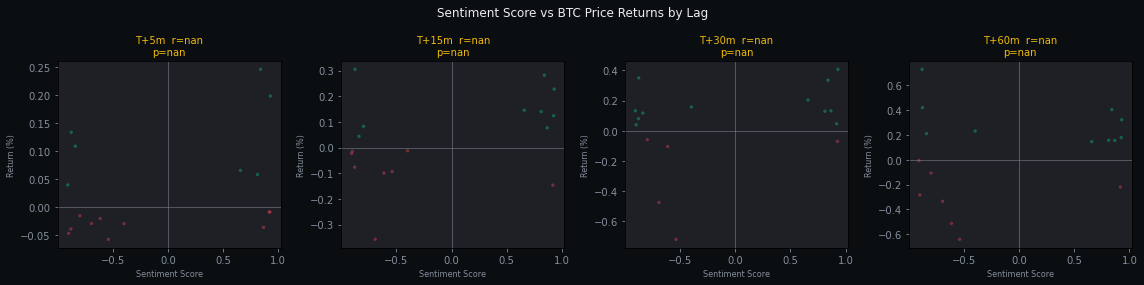

In [13]:
lags = [5, 15, 30, 60]
cols = [f'return_{l}m' for l in lags]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor='#0b0e11')

for ax, lag, col in zip(axes, lags, cols):
    ax.set_facecolor('#1e2026')
    if col not in merged_df.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color='#848e9c')
        continue
    sub = merged_df[['window_score', col]].dropna()
    colors = ['#0ecb81' if y >= 0 else '#f6465d' for y in sub[col]]
    ax.scatter(sub['window_score'], sub[col], c=colors, alpha=0.3, s=6)
    row = corr_df[corr_df['lag_min'] == lag]
    if not row.empty:
        r = row.iloc[0]['r']
        p = row.iloc[0]['p_value']
        ax.set_title(f'T+{lag}m  r={r:.3f}\np={p:.4f}', color='#f0b90b', fontsize=10)
    ax.axhline(0, color='#848e9c', lw=0.5)
    ax.axvline(0, color='#848e9c', lw=0.5)
    ax.set_xlabel('Sentiment Score', color='#848e9c', fontsize=8)
    ax.set_ylabel('Return (%)', color='#848e9c', fontsize=8)
    ax.tick_params(colors='#848e9c')

fig.suptitle('Sentiment Score vs BTC Price Returns by Lag', color='#eaecef', fontsize=12)
plt.tight_layout()
plt.show()